# Solution: Confounders and Simpson's Paradox

Answer key for [`01_confounders.ipynb`](01_confounders.ipynb).


## Setup

In [1]:
import seaborn as sns  # https://seaborn.pydata.org/

penguins = sns.load_dataset("penguins")
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Task 1: Overall correlation between bill depth and length

![Culmen Depth](../../assets/09/bill_depth_length.png){height=300}

Across the full dataset there is a **negative** correlation between `bill_depth_mm` and `bill_length_mm`.


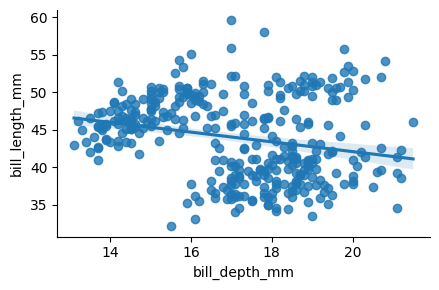

In [2]:
sns.lmplot(
    data=penguins,
    x="bill_depth_mm",
    y="bill_length_mm",
    aspect=1.5,
    height=3,
)


## Task 2: Stratify by species

When you color-code by `species`, the correlation within each group is **positive**—the opposite of the aggregate trend.


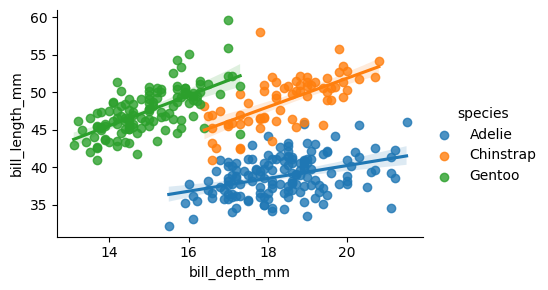

In [3]:
sns.lmplot(
    data=penguins,
    x="bill_depth_mm",
    y="bill_length_mm",
    hue="species",
    aspect=1.5,
    height=3,
)


## Task 3: Identify the confounder

**`species`** is the confounder. Different species have different bill shapes and sizes, so mixing them creates a spurious aggregate negative trend. Within each species, longer bills tend to be deeper. This is Simpson's paradox: the direction of association reverses when subgroups are combined versus examined separately.

Confounders help explain why correlation does not imply causation—we must account for variables associated with both sides of a relationship before drawing causal conclusions.


## Task 4: Is `sex` a confounder for body mass and flipper length?

Body mass and flipper length show a strong **positive** correlation overall. As penguins get heavier, their flippers tend to be longer.

When stratified by `sex`, the positive correlation is maintained within each group.


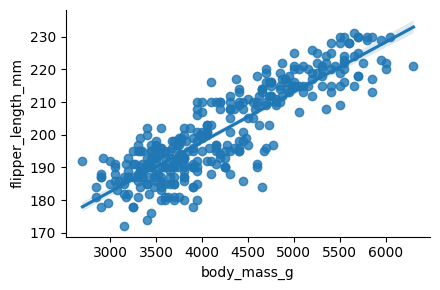

In [4]:
sns.lmplot(
    data=penguins,
    x="body_mass_g",
    y="flipper_length_mm",
    aspect=1.5,
    height=3,
)


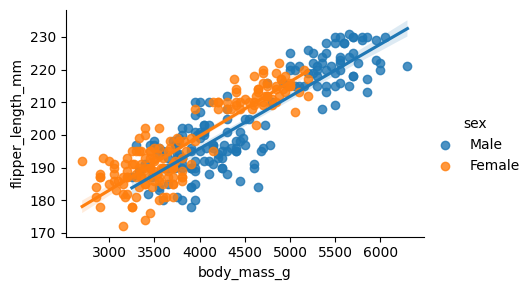

In [5]:
sns.lmplot(
    data=penguins,
    x="body_mass_g",
    y="flipper_length_mm",
    hue="sex",
    aspect=1.5,
    height=3,
)


**Answer:** `sex` is **not** a confounder here—the relationship direction and strength stay similar within males and females.


## Task 5: Is `species` a confounder for body mass and flipper length?

Stratifying by `species` also preserves the positive correlation.


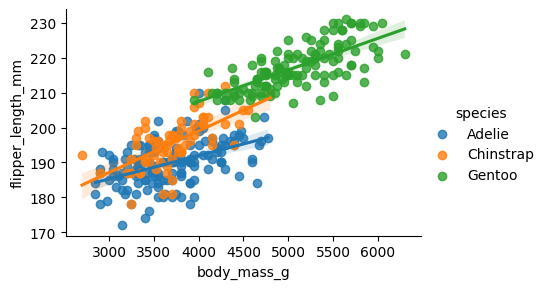

In [6]:
sns.lmplot(
    data=penguins,
    x="body_mass_g",
    y="flipper_length_mm",
    hue="species",
    aspect=1.5,
    height=3,
)


**Answer:** `species` is **not** a confounder for this pair—the aggregate trend matches what we see within each species.


## Task 6: When to stratify?

Stratify when a third variable is associated with **both** variables you are comparing and could mix subgroups with different underlying trends—as with `species` and bill dimensions.

When stratification does not change the direction or meaning of the relationship (as with body mass and flipper length across `sex` or `species`), the aggregate correlation is a reasonable summary and further grouping is less critical.
